In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import confusion_matrix

In [35]:
df = pd.read_csv('Mall_Customers.csv')

In [36]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [37]:
data = df.drop(columns=['Spending Score (1-100)'])

In [14]:
data

,CustomerID,Gender,Age,Annual Income (k$)
0,1,Male,19,15
1,2,Male,21,15
2,3,Female,20,16
3,4,Female,23,16
4,5,Female,31,17
...,...,...,...,...
195,196,Female,35,120
196,197,Female,45,126
197,198,Male,32,126
198,199,Male,32,137


In [38]:
def convert_spending_score(score):
    if score > 85:
        return 'VH'
    elif 65 <= score <= 84:
        return 'H'
    elif 40 <= score <= 64:
        return 'M'
    else:
        return 'L'

In [39]:
data['Spending_Category'] = df['Spending Score (1-100)'].apply(convert_spending_score)

In [44]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending_Category
0,1,1,19,15,L
1,2,1,21,15,H
2,3,0,20,16,L
3,4,0,23,16,H
4,5,0,31,17,M


In [45]:
from keras.utils import to_categorical

data['Gender'] = data['Gender'].apply(lambda x: 1 if x == 'Male' else 0)

data['Spending_Category'] = data['Spending_Category'].apply(lambda x: 0 if x == 'L' else (1 if x == 'M' else 2))
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending_Category
0,1,0,19,15,0
1,2,0,21,15,2
2,3,0,20,16,0
3,4,0,23,16,2
4,5,0,31,17,1


In [46]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [47]:
def hierarchical_clustering(data, n_clusters):

    Z = linkage(data, method='single')

    labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    return labels - 1

In [48]:
n_clusters_list = [3, 4]
results = []
for n_clusters in n_clusters_list:
    labels = hierarchical_clustering(data_scaled, n_clusters)
    results.append((n_clusters, labels))

In [49]:
def calculate_purity(labels_true, labels_pred):

    confusion_mat = confusion_matrix(labels_true, labels_pred)

    purity = np.sum(np.amax(confusion_mat, axis=0)) / np.sum(confusion_mat)
    return purity

In [52]:
for n_clusters, labels in results:

    spending_labels = data['Spending_Category'].astype('category').cat.codes
for n_clusters, labels in results:

    spending_labels = data['Spending_Category'].astype('category').cat.codes

    purity = calculate_purity(spending_labels, labels)
    print(f"Purity for {n_clusters} clusters: {purity:.4f}")

Purity for 3 clusters: 0.7050
Purity for 4 clusters: 0.8150


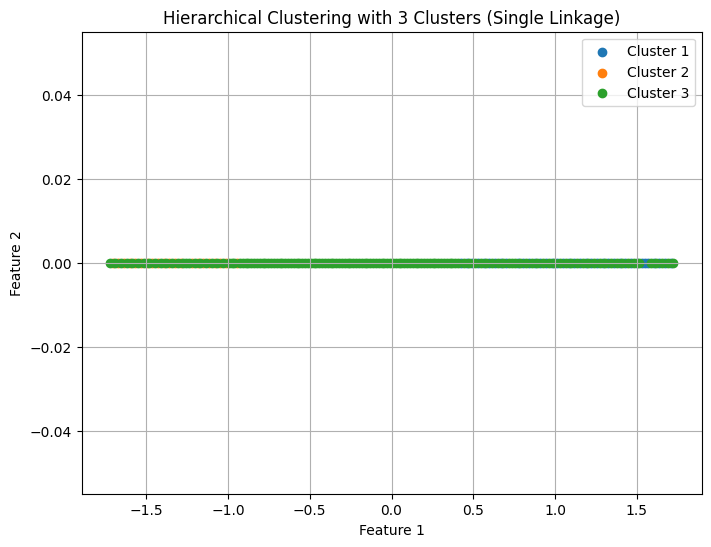

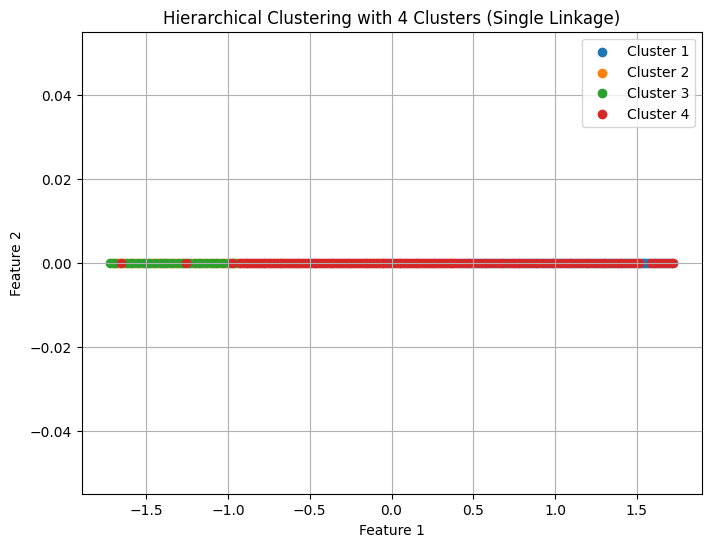

In [53]:

import matplotlib.pyplot as plt

for n_clusters, labels in results:
    plt.figure(figsize=(8, 6))
    for cluster in range(n_clusters):
        plt.scatter(
            data_scaled[labels == cluster, 0],
            data_scaled[labels == cluster, 1],
            label=f'Cluster {cluster + 1}'
        )
    plt.title(f'Hierarchical Clustering with {n_clusters} Clusters (Single Linkage)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()